In [1]:
# Импорт необходимых библиотек

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve, average_precision_score

In [2]:
df = pd.read_csv('athletes.csv')

In [3]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11538 entries, 0 to 11537
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           11538 non-null  int64  
 1   name         11538 non-null  object 
 2   nationality  11538 non-null  object 
 3   sex          11538 non-null  object 
 4   dob          11537 non-null  object 
 5   height       11208 non-null  float64
 6   weight       10879 non-null  float64
 7   sport        11538 non-null  object 
 8   gold         11538 non-null  int64  
 9   silver       11538 non-null  int64  
 10  bronze       11538 non-null  int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 991.7+ KB


,id,name,nationality,sex,dob,height,weight,sport,gold,silver,bronze
0,736041664,A Jesus Garcia,ESP,male,10/17/69,1.72,64.0,athletics,0,0,0
1,532037425,A Lam Shin,KOR,female,9/23/86,1.68,56.0,fencing,0,0,0
2,435962603,Aaron Brown,CAN,male,5/27/92,1.98,79.0,athletics,0,0,1
3,521041435,Aaron Cook,MDA,male,1/2/91,1.83,80.0,taekwondo,0,0,0
4,33922579,Aaron Gate,NZL,male,11/26/90,1.81,71.0,cycling,0,0,0


In [4]:
RANDOM_STATE = 42

**Пропуски**

In [5]:
# Общая информация о пропусках
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100

missing_df = pd.DataFrame({
    'Пропусков': missing_data,
    'Процент': missing_percent
}).sort_values('Процент', ascending=False)

print("Пропуски в данных:")
print(missing_df[missing_df['Пропусков'] > 0])

Пропуски в данных:
        Пропусков   Процент
weight        659  5.711562
height        330  2.860114
dob             1  0.008667


Пропуски в `weight`, `height` заменим медианой с учетом вида спорта и пола, рассчитаем на train.

В `dob` пропущено только одно значение. Но эта колонку можно удалить, так как рассчитывать возраст от текущей даты бессмысленно - соревнования проводились в разыне годы. Просто год рождения без данных о дате проведения соревнований, чтобы можно было рассчитать возраст атлета на момент получения награды, малоинформативен.


Также удалим `id`, `name`, они не несут полезной информации для обучения модели.

In [6]:
# Удаляем ненужные
df = df.drop(['id', 'name', 'dob'], axis=1)

**Целевая переменная**

In [7]:
# Анализ целевой переменной
print("Распределение целевой переменной sex:")
sex_counts = df['sex'].value_counts()
print(sex_counts)
print("\nВ процентном соотношении:")
print(df['sex'].value_counts(normalize=True) * 100)

Распределение целевой переменной sex:
male      6333
female    5205
Name: sex, dtype: int64

В процентном соотношении:
male      54.888196
female    45.111804
Name: sex, dtype: float64


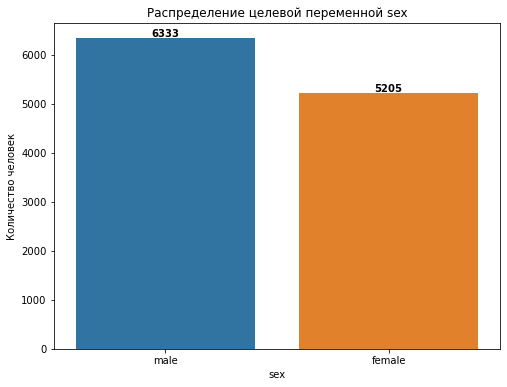

In [8]:
# Визуализация распределения целевой переменной
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='sex', data=df)

for i, v in enumerate(sex_counts.values):
    ax.text(i, v + 0.2, f'{v}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
plt.title('Распределение целевой переменной sex')
plt.xlabel('sex')
plt.ylabel('Количество человек')
plt.show()

In [9]:
imbalance_ratio = sex_counts['male'] / sex_counts['female']
print(f"Коэффициент дисбаланса: {imbalance_ratio:.1f}:1")

Коэффициент дисбаланса: 1.2:1


Коэффициент дисбаланса не очень большой, но стратификация при разделении булет не лишней.

**Предобработка**

In [10]:
# Подготовка признаков и целевой переменной
X = df.drop('sex', axis=1)
y = df['sex']

In [11]:
# Разделяем на train/test (80/20) со стратификацией
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

In [12]:
# Заполним рост и вес медианой
medians = X_train.groupby('sport')[['height', 'weight']].median()

print(medians.head())
for col in ['height', 'weight']:
    X_train[col] = X_train[col].fillna(
        X_train['sport'].map(medians[col])
    )
    X_test[col] = X_test[col].fillna(
        X_test['sport'].map(medians[col])
    )
    
    
    global_median = X_train[col].median()
    X_train[col] = X_train[col].fillna(global_median)
    X_test[col] = X_test[col].fillna(global_median)


            height  weight
sport                     
aquatics      1.78    71.0
archery       1.74    73.0
athletics     1.75    64.0
badminton     1.73    68.0
basketball    1.92    87.0


In [13]:
# Кодирование категориальных переменных
categorical_cols = ['nationality', 'sport']
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_train_encoded = encoder.fit_transform(X_train[categorical_cols])
X_test_encoded = encoder.transform(X_test[categorical_cols])



In [14]:
# Собираем
X_train_final = np.hstack([
    X_train[['height', 'weight', 'gold', 'silver', 'bronze']].values,
    X_train_encoded
])
X_test_final = np.hstack([
    X_test[['height', 'weight', 'gold', 'silver', 'bronze']].values,
    X_test_encoded
])

feature_names = ['height', 'weight', 'gold', 'silver', 'bronze'] + list(encoder.get_feature_names_out(categorical_cols))

X_train_final = pd.DataFrame(X_train_final, columns=feature_names)
X_test_final = pd.DataFrame(X_test_final, columns=feature_names)

In [15]:
# Кодирование таргета

y_train = (y_train == 'male').astype(int)
y_test = (y_test == 'male').astype(int)

**Обучение модели и построение ROC-AUC**

In [16]:
# Обучение
model = LogisticRegression(max_iter=1000)
model.fit(X_train_final, y_train)

LogisticRegression(max_iter=1000)

In [17]:
# ROC-кривая
y_proba = model.predict_proba(X_test_final)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

In [18]:
# ROC-AUC
roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.9129


In [19]:
# Расчет TPR/FPR

def calculate_tpr_fpr(y_true, y_scores, thresholds):
    tpr_list, fpr_list = [], []
    for threshold in thresholds:
        y_pred = (y_scores >= threshold).astype(int)
        TP = np.sum((y_pred == 1) & (y_true == 1))
        FP = np.sum((y_pred == 1) & (y_true == 0))
        TN = np.sum((y_pred == 0) & (y_true == 0))
        FN = np.sum((y_pred == 0) & (y_true == 1))
        TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
        FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
        tpr_list.append(TPR)
        fpr_list.append(FPR)
    return tpr_list, fpr_list

In [20]:
# Считаем TPR/FPR
thresholds = np.linspace(1, 0, 100)

tpr_manual, fpr_manual = calculate_tpr_fpr(
    y_test.values, y_proba, thresholds
)



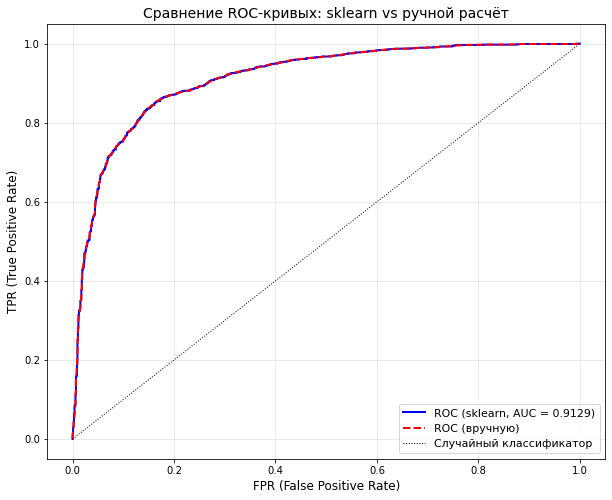

In [21]:
# Визуализация
plt.figure(figsize=(10, 8))

plt.plot(fpr, tpr, 'b-', linewidth=2, 
         label=f'ROC (sklearn, AUC = {roc_auc:.4f})')

plt.plot(fpr_manual, tpr_manual, 'r--', linewidth=2, 
         label='ROC (вручную)')

plt.plot([0, 1], [0, 1], 'k:', linewidth=1, 
         label='Случайный классификатор')

plt.xlabel('FPR (False Positive Rate)', fontsize=12)
plt.ylabel('TPR (True Positive Rate)', fontsize=12)
plt.title('Сравнение ROC-кривых: sklearn vs ручной расчёт', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()



Вывод: кривые полностью совпадают — ручной расчёт корректен.

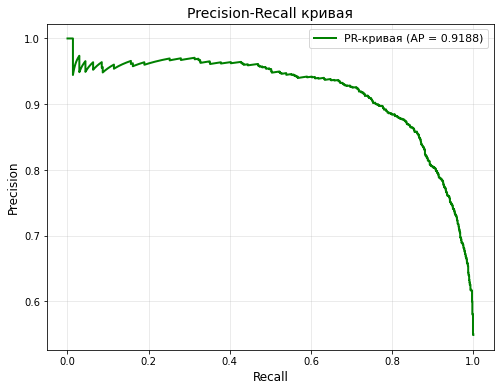

Average Precision (AP): 0.9188


In [22]:
# Метрики
precision, recall, _ = precision_recall_curve(y_test, y_proba)

ap = average_precision_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, 'g-', linewidth=2, 
         label=f'PR-кривая (AP = {ap:.4f})')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall кривая', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

print(f"Average Precision (AP): {ap:.4f}")

In [23]:
def calculate_roc_auc_manual(fpr, tpr):
    """Считает ROC-AUC методом трапеций."""
    sorted_idx = np.argsort(fpr)
    fpr_sorted = np.array(fpr)[sorted_idx]
    tpr_sorted = np.array(tpr)[sorted_idx]
    
    auc = 0
    for i in range(1, len(fpr_sorted)):
        auc += (fpr_sorted[i] - fpr_sorted[i-1]) * (tpr_sorted[i] + tpr_sorted[i-1]) / 2
    return auc

roc_auc_manual = calculate_roc_auc_manual(fpr_manual, tpr_manual)

print(f"ROC-AUC (sklearn):  {roc_auc:.6f}")
print(f"ROC-AUC (вручную):  {roc_auc_manual:.6f}")
print(f"Разница:            {abs(roc_auc - roc_auc_manual):.6f}")

ROC-AUC (sklearn):  0.912852
ROC-AUC (вручную):  0.912891
Разница:            0.000038


### Выводы

**a) Как по графикам сделать вывод о качестве модели?**

1. **ROC-кривая:**
   - ROC-AUC = 0.9129 — хорошее качество.
   - Кривая значительно выше диагонали, значит модель различает пол намного лучше случайного угадывания.
   

2. **Precision-Recall кривая:**
   - Average Precision — высокое значение.
   - Кривая показывает хороший баланс между точностью и полнотой.
   

3. **Сравнение sklearn vs вручную:**
   - Кривые полностью совпадают.
   - Ручной расчёт корректен.
   

4. **Оценка модели:**
   - ROC-AUC > 0.9 - модель хорошо различает мужчин и женщин.
   - Основные признаки: `sport`, `height`, `weight`.
   

**b) Может ли ROC-кривая проходить ниже диагонали?**

Да, может. Это означает, что модель работает хуже случайного угадывания и ROC-AUC < 0.5:
